In [1]:
import sys
from pathlib import Path

# Adds 'dir1' (the parent directory) to Jupyter's path
sys.path.append(str(Path.cwd().parent))

import tps_pinn 

In [2]:
from scipy.stats import qmc
from scipy.io import loadmat
from scipy.interpolate import RegularGridInterpolator, griddata
import numpy as np
import time
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
import torch
torch.manual_seed(0)
torch.set_default_dtype(torch.float64)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [3]:
# Por enunciado
# Puntos de colocación y de datos del TP1
N_PDE = 1000
N_BC = 100
# Pesos de ponderacion
# LAMBDA_BC = 10
# LAMBDA_PDE = 100
LAMBDA_BC = 10
LAMBDA_PDE = 1
# Límites
X_LIM = (0, 1)
Y_LIM = (0, 1)
# Delta de Re para sensibilidad
RE = 100
DELTA_RE = 5
# Parametros de la red
# EPOCHS = 6000
EPOCHS = 10000
HIDDEN_LAYERS = 4
HIDDEN_UNITS = 64
ACTIVATION = torch.nn.Tanh()

In [4]:
# Importo data de ground truth
pressure_data = loadmat('../data/pressure.mat')
velocity_data = loadmat('../data/velocity.mat')
X_data_all = torch.tensor(np.hstack((pressure_data['x'].transpose(), pressure_data['y'].transpose())), dtype=torch.float32)
y_data_all = torch.tensor(np.hstack((pressure_data['p'].transpose(), velocity_data['u'].transpose(),velocity_data['v'].transpose())), dtype=torch.float32)


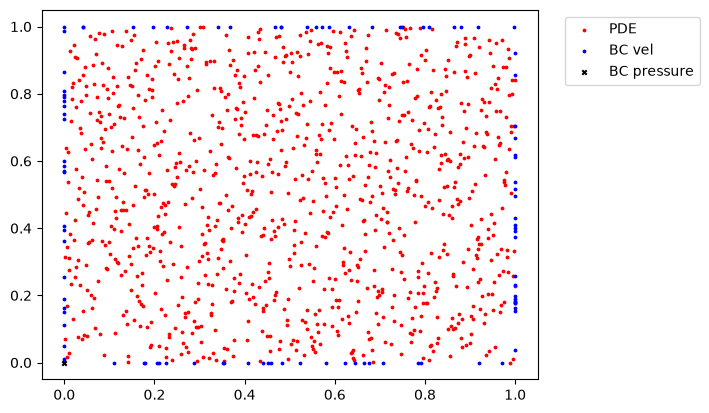

In [5]:
lhs = qmc.LatinHypercube(d=2)

X_pde = lhs.random(n=N_PDE)
X_pde = torch.tensor(X_pde)
X_bc_u, y_bc_u, X_bc_p, y_bc_p = tps_pinn.set_X_bc(N_BC)
tps_pinn.plot_points(X_pde, X_bc_u, X_bc_p)

In [6]:
base_params = {
    'hidden_layers': HIDDEN_LAYERS,
    'hidden_units': HIDDEN_UNITS,
    'activation': ACTIVATION,
    'device': device
}
tags = ['PDE', 'BC_VEL', 'BC_P']
dataset = [
    torch.utils.data.TensorDataset(X_pde, torch.zeros(N_PDE, 1)),   # PDE
    torch.utils.data.TensorDataset(X_bc_u, y_bc_u),                 # BC velocity
    torch.utils.data.TensorDataset(X_bc_p, y_bc_p),                 # BC pressure
]

In [7]:
models = {}
for re in [RE, RE+DELTA_RE]:
    params = base_params
    params["Re"] = re

    model = tps_pinn.PINN(params).to(device)

    # start_time = time.perf_counter()
    # model, pde_loss_history, bc_vel_loss_history, bc_p_loss_history, data_loss_history, l2_error, opt = tps_pinn.train_pinn(
    #     model,
    #     EPOCHS,
    #     dataset,
    #     device,
    #     False, # use_data
    #     X_data_all, y_data_all,
    #     lambdas = {
    #         "pde": LAMBDA_PDE,
    #         "bc_u": LAMBDA_BC, 
    #         "bc_p": LAMBDA_BC, 
    #     }
    # )
    # elap_time = time.perf_counter() - start_time
    # print(f"Tiempo de entrenamiento: {elap_time:.1f}s")

    # model_path = f"re{re}.pth"
    # torch.save(model.state_dict(), model_path)

    state_dict = torch.load(f"re{re}.pth", map_location=torch.device(device))
    model.load_state_dict(state_dict)

    models[re] = model

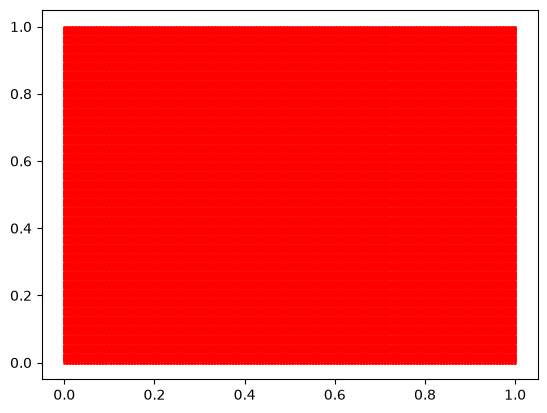

In [8]:
# Grilla de 300x300 uniforme
STEPS = 300
x_sens = torch.linspace(0,1,steps=STEPS)
y_sens = torch.linspace(0,1,steps=STEPS)
gridx, gridy = torch.meshgrid(x_sens, y_sens, indexing='ij')
X_sens = torch.stack((gridx, gridy), dim=-1).reshape(-1,2)
plt.scatter(X_sens[:, 0], X_sens[:, 1], s=1, color='red', label='Sensibilidad: 300x300')
X_sens = X_sens.to(device)

In [9]:
pred = {}
for re in [RE, RE+DELTA_RE]:
    models[re].eval()
    y_pred = models[re](X_sens)
    pred[re] = y_pred

SIGMA = 0.01
eps = pow((1/SIGMA) * (pred[RE + DELTA_RE][:,1] - pred[RE][:,1])/DELTA_RE,2) + pow((1/SIGMA) * (pred[RE + DELTA_RE][:,2] - pred[RE][:,2])/DELTA_RE,2)
eps = torch.sqrt(eps)

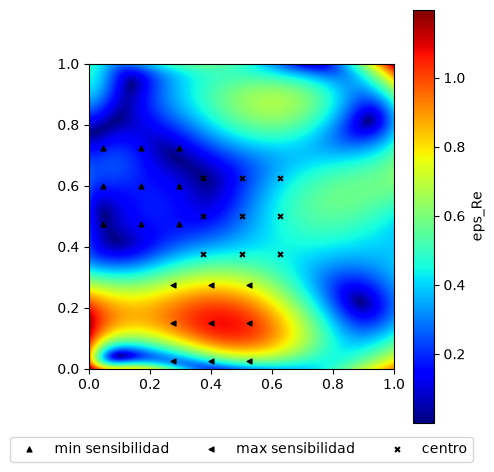

In [10]:
fig, ax = plt.subplots(1,1,figsize=(5,5))
ax.imshow(
    griddata(
        X_sens.cpu().numpy(),
        eps.detach().cpu().numpy(),
        np.meshgrid(np.linspace(0, 1, 300), np.linspace(0, 1, 300)),
        method='cubic'
    ),
    origin='lower',
    extent=(0, 1, 0, 1),
    cmap='jet'
)

L_SENSOR = 0.25

sensores = [(0.17,0.6), (0.4,0.15), (0.5,0.5)]
label_sensor = ['min sensibilidad', 'max sensibilidad', 'centro']
markers_sensor = ['^', '<', 'x']
sensores_points = [torch.stack(torch.meshgrid(torch.linspace(centro[0] - L_SENSOR/2, centro[0] + L_SENSOR/2, 3), torch.linspace(centro[1] - L_SENSOR/2, centro[1] + L_SENSOR/2, 3), indexing='ij'), dim=-1).reshape(-1,2) for centro in sensores]

[ax.scatter(points[:,0], points[:,1], label=label, marker=marker, color='black', s=12) for points, label, marker in zip(sensores_points, label_sensor, markers_sensor)]
ax.legend(bbox_to_anchor=(0.5, -0.2), loc='upper center', ncols=3)

fig.colorbar(ax.images[0], ax=ax, label='eps_Re')

plt.tight_layout()
plt.show()

In [11]:

print(X_sens.shape)
print(eps.shape)

interp_func = RegularGridInterpolator(
    (np.unique(X_sens.cpu().detach()[:,0]), np.unique(X_sens.cpu().detach()[:,1])),
    eps.cpu().detach().reshape(STEPS, STEPS), 
    method='linear')

for sensor, puntos in zip(label_sensor, sensores_points):
    eps_sensor = interp_func(np.array(puntos))
    eps_sensor = [eps_i ** 2 for eps_i in eps_sensor]
    identificabilidad = np.sum(eps_sensor)
    print(f"{sensor} -> identificabilidad = {identificabilidad:.4f}")
    

torch.Size([90000, 2])
torch.Size([90000])
min sensibilidad -> identificabilidad = 0.1823
max sensibilidad -> identificabilidad = 5.3622
centro -> identificabilidad = 1.0578


/tmp/ipykernel_1267443/2714748265.py:10: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  eps_sensor = interp_func(np.array(puntos))


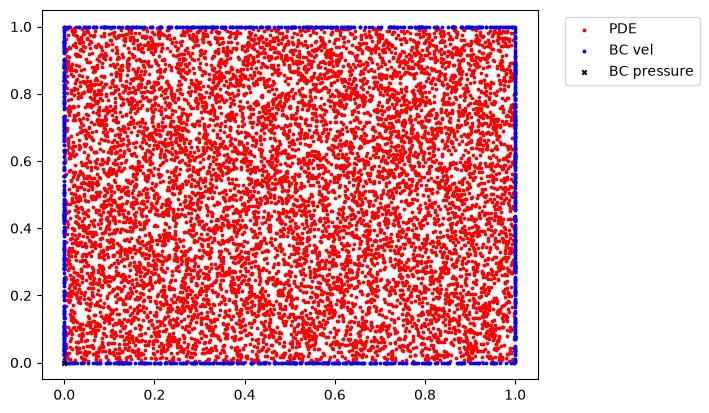

In [12]:
# Por enunciado
# Puntos de colocación y de datos
N_PDE = 10000
N_BC = 1000

lhs = qmc.LatinHypercube(d=2)

X_pde = lhs.random(n=N_PDE)
X_pde = torch.tensor(X_pde)
X_bc_u, y_bc_u, X_bc_p, y_bc_p = tps_pinn.set_X_bc(N_BC)
tps_pinn.plot_points(X_pde, X_bc_u, X_bc_p)


In [39]:
base_params = {
    'hidden_layers': HIDDEN_LAYERS,
    'hidden_units': HIDDEN_UNITS,
    'activation': ACTIVATION,
    'device': device
}

tags = ['PDE', 'BC_VEL', 'BC_P', 'SENSOR']
dataset = [
    torch.utils.data.TensorDataset(X_pde, torch.zeros(N_PDE, 1)),   # PDE
    torch.utils.data.TensorDataset(X_bc_u, y_bc_u),                 # BC velocity
    torch.utils.data.TensorDataset(X_bc_p, y_bc_p),                 # BC pressure
]

EPOCHS_VANILLA = 3000
CKPT_PATH = "vanilla_inverse.pth"

lambdas = {
    "pde": LAMBDA_PDE,
    "bc_u": LAMBDA_BC,
    "bc_p": LAMBDA_BC,
    "sensor": 2e+2
}

# Valor inicial del parámetro inverso: el Re es desconocido, arranco de un valor al azar
# inv_re_0 = 1.0 / (10 ** torch.rand(1, device=device))
inv_re_0 = 1.0 / (torch.tensor(50.0))

##############################################################################
# Etapa 1: PINN "vanilla" con el Re inicial FIJO (sin sensores, sin optimizar Re)
##############################################################################
# params = dict(base_params)
# params['Re'] = float(1 / inv_re_0)   # float plano: no es parámetro, no se optimiza

# model = tps_pinn.PINN(params).to(device)

# start_time = time.perf_counter()
# model, *_ = tps_pinn.train_pinn(
#     model,
#     EPOCHS_VANILLA,
#     dataset,          # sin sensores
#     device,
#     False,            # use_data
#     X_data_all, y_data_all,
#     lambdas = lambdas,
#     tags = ['PDE', 'BC_VEL', 'BC_P'],
# )
# elap_time = time.perf_counter() - start_time
# print(f"\nTiempo de entrenamiento vanilla: {elap_time:.1f}s")

# # Guardo pesos + el inv_Re con el que fue entrenado: el checkpoint sólo es válido
# # junto a ese valor, porque la red se ajustó a ese Re en particular
# torch.save({'model': model.state_dict(), 'inv_re': inv_re_0.cpu()}, CKPT_PATH)

##############################################################################
# Etapa 1 (alternativa): recuperar el checkpoint y saltear las 3000 épocas
# -> descomentar este bloque y comentar el de la Etapa 1
##############################################################################
ckpt = torch.load(CKPT_PATH, map_location=device)
inv_re_0 = ckpt['inv_re'].to(device)
params = dict(base_params)
params['Re'] = float(1 / inv_re_0)
model = tps_pinn.PINN(params).to(device)
model.load_state_dict(ckpt['model'])


<All keys matched successfully>

In [31]:
base_params = {
    'hidden_layers': HIDDEN_LAYERS,
    'hidden_units': HIDDEN_UNITS,
    'activation': ACTIVATION,
    'device': device
}

# Interpolamos el valor en los 9 puntos de sensores
sensores_data = [
    torch.tensor(griddata(X_data_all, y_data_all[:,1:], points, method='linear'))
    for points in sensores_points
]

tags = ['PDE', 'BC_VEL', 'BC_P', 'SENSOR']
dataset = [
    torch.utils.data.TensorDataset(X_pde, torch.zeros(N_PDE, 1)),   # PDE
    torch.utils.data.TensorDataset(X_bc_u, y_bc_u),                 # BC velocity
    torch.utils.data.TensorDataset(X_bc_p, y_bc_p),                 # BC pressure
]

param_hists = {}
models = {}
final_re = {}
loss_hists = {}

for sensor, sensor_points, sensor_data in zip(label_sensor, sensores_points, sensores_data):
    dataset_sensor = dataset + [torch.utils.data.TensorDataset(sensor_points, sensor_data)]

    EPOCHS_VANILLA = 3000
    CKPT_PATH = "vanilla_inverse.pth"

    param_hists[sensor] = {}
    models[sensor] = {}
    final_re[sensor] = {}
    loss_hists[sensor] = {}

    for lambda_sensor in [1e+2, 1e+3, 1e+4]:
        lambdas = {
            "pde": LAMBDA_PDE,
            "bc_u": LAMBDA_BC,
            "bc_p": LAMBDA_BC,
            "sensor": lambda_sensor
        }

        # Inicializo con Re=50. Relativamente cerca del objetivo Re=100
        inv_re_0 = 1.0 / (torch.tensor(50.0))

        # Recupero el modelo vanilla ya entrenado
        ckpt = torch.load(CKPT_PATH, map_location=device)
        inv_re_0 = ckpt['inv_re'].to(device)
        params = dict(base_params)
        params['Re'] = float(1 / inv_re_0)
        model = tps_pinn.PINN(params).to(device)
        model.load_state_dict(ckpt['model'])
        
        inv_re = torch.nn.Parameter(inv_re_0.clone())

        EPOCHS = 13000
        model, pde_loss_history, bc_vel_loss_history, bc_p_loss_history, data_loss_history, l2_error, opt, param_hist, grad_hist = tps_pinn.train_pinn_inverse(
            model,
            inv_re,
            # log_re,
            EPOCHS - EPOCHS_VANILLA,
            dataset_sensor,
            device,
            X_data_all, y_data_all,
            lambdas = lambdas,
            tags = tags,
            epochs_no_sensor = 0,
            lr_param = 1e-3,
            param_update="sgd",
            param_block=20
        )

        param_hists[sensor][lambda_sensor] = param_hist
        models[sensor][lambda_sensor] = model
        final_re[sensor][lambda_sensor] = param_hist[-1]
        loss_history = [pde + bc_vel + bc_p for pde, bc_vel, bc_p in zip(pde_loss_history, bc_vel_loss_history, bc_p_loss_history)]
        loss_hists[sensor][lambda_sensor] = loss_history

Comenzando entrenamiento del modelo...
Epoch 2, PDE Loss: 0.001492, BC vel. Loss: 0.014501, BC pres. Loss: 0.000000, DATA Loss: N/A, SENSOR Loss: 0.010452, Re: 50.2, grad: +6.570e-02, Re*: nan

/home/jiteich/repos/ceia/pinn_ceia/TPs/tps_pinn.py:281: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_pred = pinn(torch.tensor(X_data_all, dtype=torch.float64).to(device)).detach().cpu().numpy()


Epoch 9999, PDE Loss: 0.466950, BC vel. Loss: 0.004309, BC pres. Loss: 0.000002, DATA Loss: N/A, SENSOR Loss: 0.000129, Re: 5966.4, grad: +2.004e-01, Re*: nannComenzando entrenamiento del modelo...
Epoch 3839, PDE Loss: 1.039528, BC vel. Loss: 0.061347, BC pres. Loss: 0.002311, DATA Loss: N/A, SENSOR Loss: 0.016633, Re: 23.5, grad: +7.427e-05, Re*: nan
Corte por convergencia en epoch 3840: Re=23.5 (mediana; cambio rel. 4.3e-03 entre ventanas de 500 épocas), PDE loss en plateau (cambio rel. 1.4e-03)
Comenzando entrenamiento del modelo...
Epoch 2279, PDE Loss: 0.554854, BC vel. Loss: 0.108665, BC pres. Loss: 0.000108, DATA Loss: N/A, SENSOR Loss: 0.089168, Re: 23.5, grad: -1.329e-03, Re*: nan
Corte por convergencia en epoch 2280: Re=23.5 (mediana; cambio rel. 5.0e-03 entre ventanas de 500 épocas), PDE loss en plateau (cambio rel. 4.0e-05)
Comenzando entrenamiento del modelo...
Epoch 3579, PDE Loss: 0.046442, BC vel. Loss: 0.010521, BC pres. Loss: 0.005885, DATA Loss: N/A, SENSOR Loss: 0.

In [32]:
RE_TARGET = 100

print(f"{'sensor':<20} {'lambda_sensor':>14} {'Re final':>10} {'error %':>10}")
print("-" * 58)
for sensor in label_sensor:
    for lambda_sensor, re_final in final_re[sensor].items():
        error = 100 * (re_final - RE_TARGET) / RE_TARGET
        print(f"{sensor:<20} {lambda_sensor:>14.0e} {re_final:>10.2f} {error:>+9.2f}%")


sensor                lambda_sensor   Re final    error %
----------------------------------------------------------
min sensibilidad              1e+02    5966.36  +5866.36%
min sensibilidad              1e+03      23.51    -76.49%
min sensibilidad              1e+04      23.48    -76.52%
max sensibilidad              1e+02      78.29    -21.71%
max sensibilidad              1e+03     167.75    +67.75%
max sensibilidad              1e+04      99.90     -0.10%
centro                        1e+02      96.94     -3.06%
centro                        1e+03     159.68    +59.68%
centro                        1e+04      51.56    -48.44%


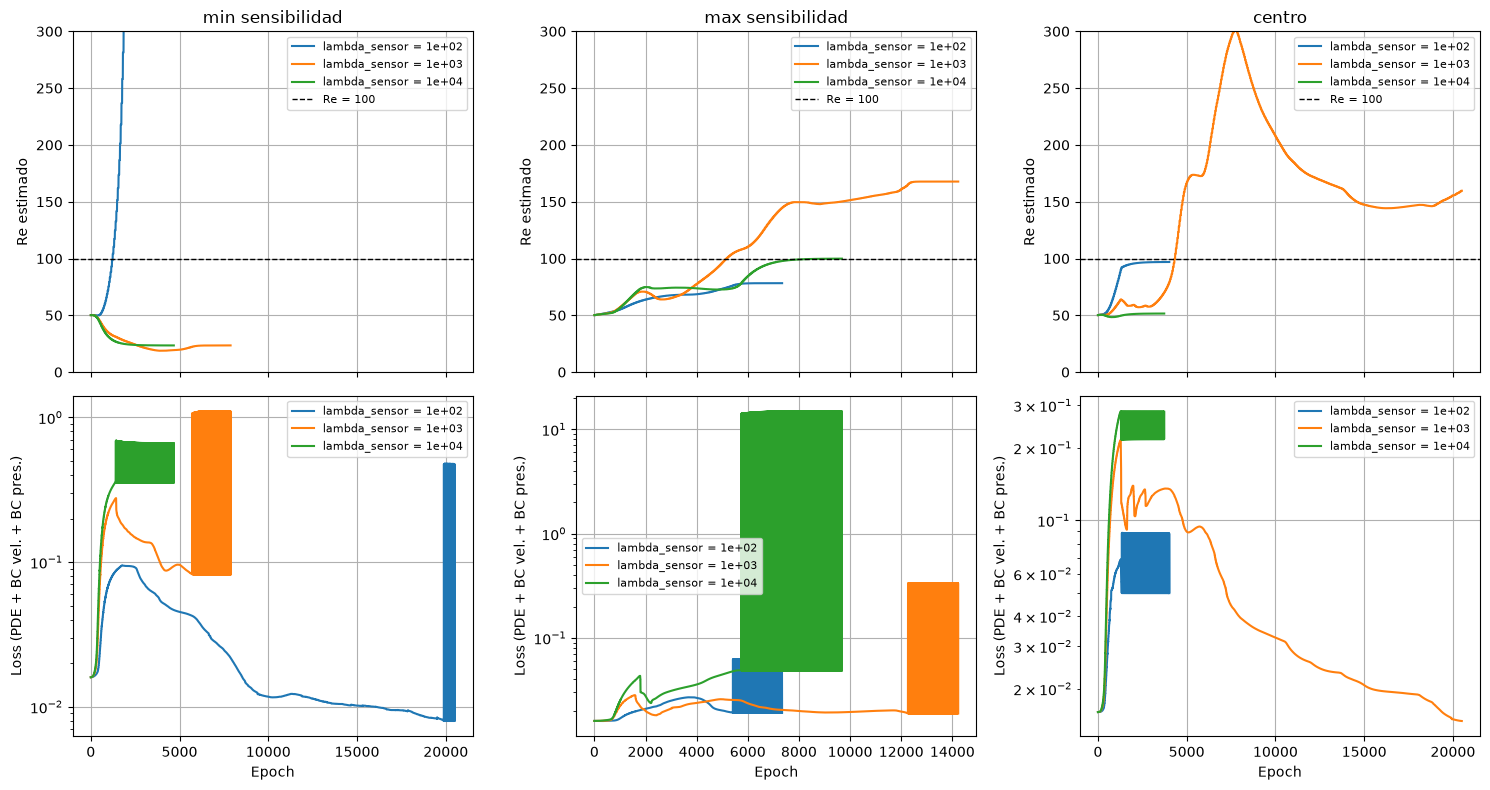

In [33]:
fig, axes = plt.subplots(2, len(label_sensor), figsize=(5 * len(label_sensor), 8), sharex='col')

for col, sensor in enumerate(label_sensor):
    ax_re, ax_loss = axes[0, col], axes[1, col]

    for lambda_sensor in sorted(param_hists[sensor]):
        param_hist = param_hists[sensor][lambda_sensor]
        loss_history = loss_hists[sensor][lambda_sensor]
        # param_hist se registra cada param_block epochs -> reescalo el eje x a epochs
        epochs_param = np.linspace(0, len(loss_history), num=len(param_hist))

        ax_re.plot(epochs_param, param_hist, label=f"lambda_sensor = {lambda_sensor:.0e}")
        ax_loss.plot(loss_history, label=f"lambda_sensor = {lambda_sensor:.0e}")

    ax_re.axhline(RE_TARGET, color='black', linestyle='--', linewidth=1, label=f'Re = {RE_TARGET}')
    ax_re.set_title(sensor)
    ax_re.set_ylabel('Re estimado')
    ax_re.set_ylim(0, 300)
    ax_re.grid()
    ax_re.legend(fontsize=8)

    ax_loss.set_ylabel('Loss (PDE + BC vel. + BC pres.)')
    ax_loss.set_xlabel('Epoch')
    ax_loss.set_yscale('log')
    ax_loss.grid()
    ax_loss.legend(fontsize=8)

plt.tight_layout()
plt.show()


In [36]:
# np.random.normal(loc=0.0, scale=sigma, size=data.shape)

sigma = 0.01 # 1%
base_params = {
    'hidden_layers': HIDDEN_LAYERS,
    'hidden_units': HIDDEN_UNITS,
    'activation': ACTIVATION,
    'device': device
}

# Interpolamos el valor en los 9 puntos de sensores
# Agregamos error normal con sigma=0.01
sensores_data = [
    torch.tensor(griddata(X_data_all, y_data_all[:,1:], points, method='linear') + np.random.normal(loc=0.0, scale=sigma, size=points.shape))
    for points in sensores_points
]
# sensores_data = [

# ]

tags = ['PDE', 'BC_VEL', 'BC_P', 'SENSOR']
dataset = [
    torch.utils.data.TensorDataset(X_pde, torch.zeros(N_PDE, 1)),   # PDE
    torch.utils.data.TensorDataset(X_bc_u, y_bc_u),                 # BC velocity
    torch.utils.data.TensorDataset(X_bc_p, y_bc_p),                 # BC pressure
]

param_hists = {}
models = {}
final_re = {}
loss_hists = {}

for sensor, sensor_points, sensor_data in zip(label_sensor, sensores_points, sensores_data):
    dataset_sensor = dataset + [torch.utils.data.TensorDataset(sensor_points, sensor_data)]

    EPOCHS_VANILLA = 3000
    CKPT_PATH = "vanilla_inverse.pth"

    param_hists[sensor] = {}
    models[sensor] = {}
    final_re[sensor] = {}
    loss_hists[sensor] = {}

    for lambda_sensor in [1e+2, 1e+3, 1e+4]:
        lambdas = {
            "pde": LAMBDA_PDE,
            "bc_u": LAMBDA_BC,
            "bc_p": LAMBDA_BC,
            "sensor": lambda_sensor
        }

        # Inicializo con Re=50. Relativamente cerca del objetivo Re=100
        inv_re_0 = 1.0 / (torch.tensor(50.0))

        # Recupero el modelo vanilla ya entrenado
        ckpt = torch.load(CKPT_PATH, map_location=device)
        inv_re_0 = ckpt['inv_re'].to(device)
        params = dict(base_params)
        params['Re'] = float(1 / inv_re_0)
        model = tps_pinn.PINN(params).to(device)
        model.load_state_dict(ckpt['model'])
        
        inv_re = torch.nn.Parameter(inv_re_0.clone())

        EPOCHS = 13000
        model, pde_loss_history, bc_vel_loss_history, bc_p_loss_history, data_loss_history, l2_error, opt, param_hist, grad_hist = tps_pinn.train_pinn_inverse(
            model,
            inv_re,
            # log_re,
            EPOCHS - EPOCHS_VANILLA,
            dataset_sensor,
            device,
            X_data_all, y_data_all,
            lambdas = lambdas,
            tags = tags,
            epochs_no_sensor = 0,
            lr_param = 1e-3,
            param_update="sgd",
            param_block=20
        )

        param_hists[sensor][lambda_sensor] = param_hist
        models[sensor][lambda_sensor] = model
        final_re[sensor][lambda_sensor] = param_hist[-1]
        loss_history = [pde + bc_vel + bc_p for pde, bc_vel, bc_p in zip(pde_loss_history, bc_vel_loss_history, bc_p_loss_history)]
        loss_hists[sensor][lambda_sensor] = loss_history

Comenzando entrenamiento del modelo...
Epoch 9999, PDE Loss: 0.011195, BC vel. Loss: 0.004011, BC pres. Loss: 0.000109, DATA Loss: N/A, SENSOR Loss: 0.000202, Re: 832.3, grad: -2.319e-01, Re*: nannnComenzando entrenamiento del modelo...
Epoch 2259, PDE Loss: 0.103056, BC vel. Loss: 0.042733, BC pres. Loss: 0.000006, DATA Loss: N/A, SENSOR Loss: 0.001593, Re: 26.6, grad: -1.061e-03, Re*: nan
Corte por convergencia en epoch 2260: Re=26.6 (mediana; cambio rel. 4.7e-03 entre ventanas de 500 épocas), PDE loss en plateau (cambio rel. 1.2e-06)
Comenzando entrenamiento del modelo...
Epoch 5859, PDE Loss: 8.675049, BC vel. Loss: 0.131482, BC pres. Loss: 0.022932, DATA Loss: N/A, SENSOR Loss: 0.125529, Re: 60.1, grad: +1.908e-05, Re*: nan
Corte por convergencia en epoch 5860: Re=60.1 (mediana; cambio rel. 4.4e-03 entre ventanas de 500 épocas), PDE loss en plateau (cambio rel. 2.1e-04)
Comenzando entrenamiento del modelo...
Epoch 2479, PDE Loss: 1.446101, BC vel. Loss: 1.286838, BC pres. Loss: 0.

In [37]:
RE_TARGET = 100

print(f"{'sensor':<20} {'lambda_sensor':>14} {'Re final':>10} {'error %':>10}")
print("-" * 58)
for sensor in label_sensor:
    for lambda_sensor, re_final in final_re[sensor].items():
        error = 100 * (re_final - RE_TARGET) / RE_TARGET
        print(f"{sensor:<20} {lambda_sensor:>14.0e} {re_final:>10.2f} {error:>+9.2f}%")



sensor                lambda_sensor   Re final    error %
----------------------------------------------------------
min sensibilidad              1e+02     832.26   +732.26%
min sensibilidad              1e+03      26.58    -73.42%
min sensibilidad              1e+04      60.06    -39.94%
max sensibilidad              1e+02      69.44    -30.56%
max sensibilidad              1e+03     192.09    +92.09%
max sensibilidad              1e+04     598.19   +498.19%
centro                        1e+02     101.95     +1.95%
centro                        1e+03      56.36    -43.64%
centro                        1e+04      51.51    -48.49%


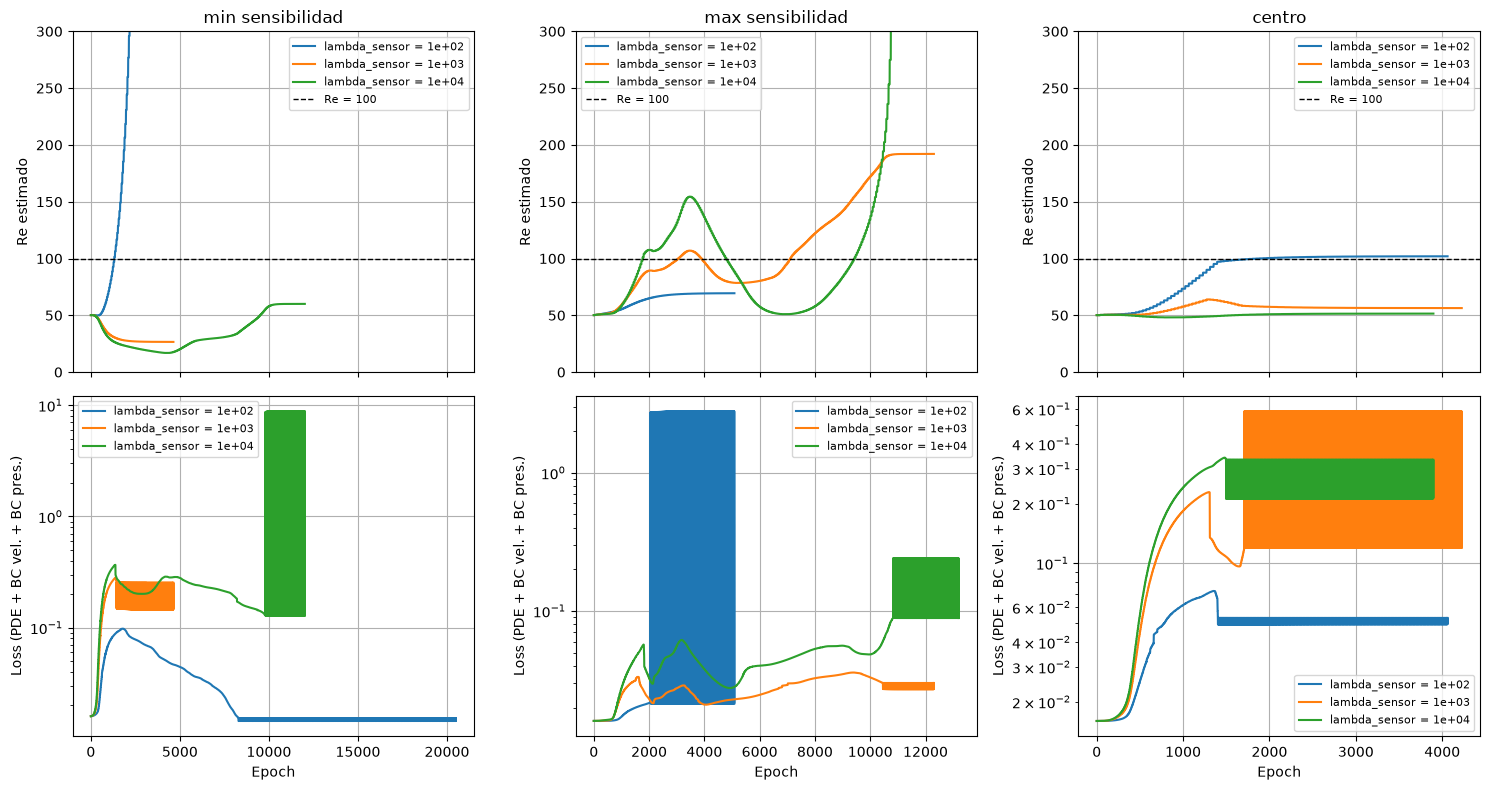

In [38]:
fig, axes = plt.subplots(2, len(label_sensor), figsize=(5 * len(label_sensor), 8), sharex='col')

for col, sensor in enumerate(label_sensor):
    ax_re, ax_loss = axes[0, col], axes[1, col]

    for lambda_sensor in sorted(param_hists[sensor]):
        param_hist = param_hists[sensor][lambda_sensor]
        loss_history = loss_hists[sensor][lambda_sensor]
        # param_hist se registra cada param_block epochs -> reescalo el eje x a epochs
        epochs_param = np.linspace(0, len(loss_history), num=len(param_hist))

        ax_re.plot(epochs_param, param_hist, label=f"lambda_sensor = {lambda_sensor:.0e}")
        ax_loss.plot(loss_history, label=f"lambda_sensor = {lambda_sensor:.0e}")

    ax_re.axhline(RE_TARGET, color='black', linestyle='--', linewidth=1, label=f'Re = {RE_TARGET}')
    ax_re.set_title(sensor)
    ax_re.set_ylabel('Re estimado')
    ax_re.set_ylim(0, 300)
    ax_re.grid()
    ax_re.legend(fontsize=8)

    ax_loss.set_ylabel('Loss (PDE + BC vel. + BC pres.)')
    ax_loss.set_xlabel('Epoch')
    ax_loss.set_yscale('log')
    ax_loss.grid()
    ax_loss.legend(fontsize=8)

plt.tight_layout()
plt.show()